In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Environment Ready!")

Environment Ready!


In [2]:
df=pd.read_csv("StudentsPerformance.csv")

In [3]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [5]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [7]:
# Null Values
print("=== Null Values ===")
print(df.isnull().sum())

=== Null Values ===
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [9]:
# Negative Values
print("\n=== Negative Values ===")
numeric_cols = df.select_dtypes(include='number').columns
found_negative=False
for col in numeric_cols:
    negative_count = (df[col] < 0).sum()
    if negative_count > 0:
        found_negative=True
        print(f"{col}: {negative_count} negative values")
        print(df[df[col]<0])
    if not found_negative:
        print("No negative values found in any numeric column.")


=== Negative Values ===
No negative values found in any numeric column.
No negative values found in any numeric column.
No negative values found in any numeric column.


In [13]:
# Incorrect Formats
print("\n=== Incorrect Formats ===")
print("Out-of-range score values (expected 0-100):")
for col in numeric_cols:
    out_of_range=df[(df[col]<0) | (df[col]>100)]
    print(f" {col}:{len(out_of_range)} out of range values(s)")


=== Incorrect Formats ===
Out-of-range score values (expected 0-100):
 math score:0 out of range values(s)
 reading score:0 out of range values(s)
 writing score:0 out of range values(s)


In [17]:
# Calculate Subject Averages
avg_math=df["math score"].mean()
avg_read=df["reading score"].mean()
avg_write=df["writing score"].mean()

averages={
    "Math Average":avg_math,
    "Reading Average":avg_read,
    "Writing Average":avg_write
}

In [18]:
averages

{'Math Average': np.float64(66.089),
 'Reading Average': np.float64(69.169),
 'Writing Average': np.float64(68.054)}

In [19]:
# Identify Top 5 Students
df["total_score"]=df["math score"]+df["reading score"]+df["writing score"]
top_students=df.sort_values(by="total_score",ascending=False).head(5)

In [20]:
top_students

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score
962,female,group E,associate's degree,standard,none,100,100,100,300
458,female,group E,bachelor's degree,standard,none,100,100,100,300
916,male,group E,bachelor's degree,standard,completed,100,100,100,300
114,female,group E,bachelor's degree,standard,completed,99,100,100,299
179,female,group D,some high school,standard,completed,97,100,100,297


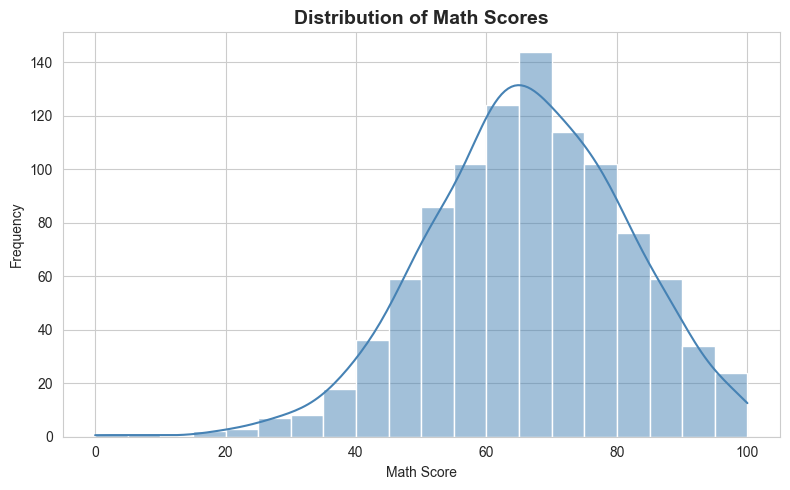

In [21]:
sns.set_style("whitegrid")

# Creating an overall average score column
df["average score"]=df[["math score","reading score","writing score"]].mean(axis=1)

# Distribution of Math Scores
plt.figure(figsize=(8,5))
sns.histplot(df["math score"],bins=20,kde=True,color='steelblue')
plt.title("Distribution of Math Scores",fontsize=14,fontweight='bold')
plt.xlabel('Math Score')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

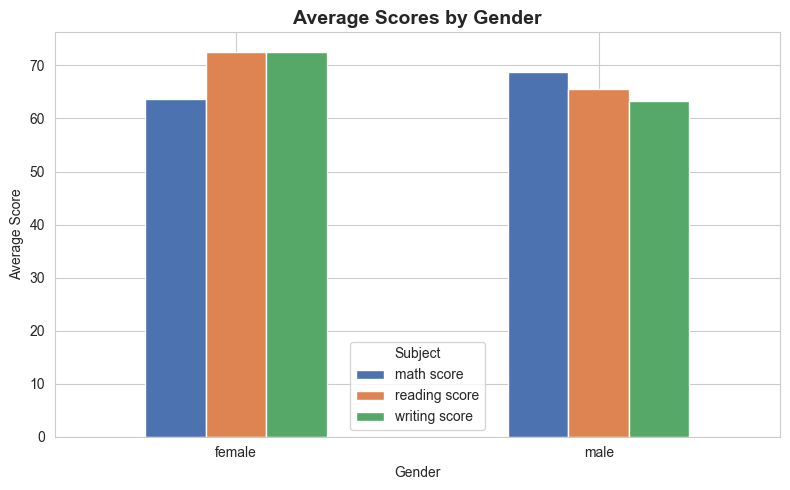

In [22]:
# Average Scores by Gender
avg_by_gender=df.groupby('gender')[['math score','reading score','writing score']].mean()
avg_by_gender.plot(kind='bar',figsize=(8,5),color=['#4c72b0','#dd8452','#55a868'])
plt.title('Average Scores by Gender',fontsize=14,fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.legend(title='Subject')
plt.tight_layout()
plt.show()

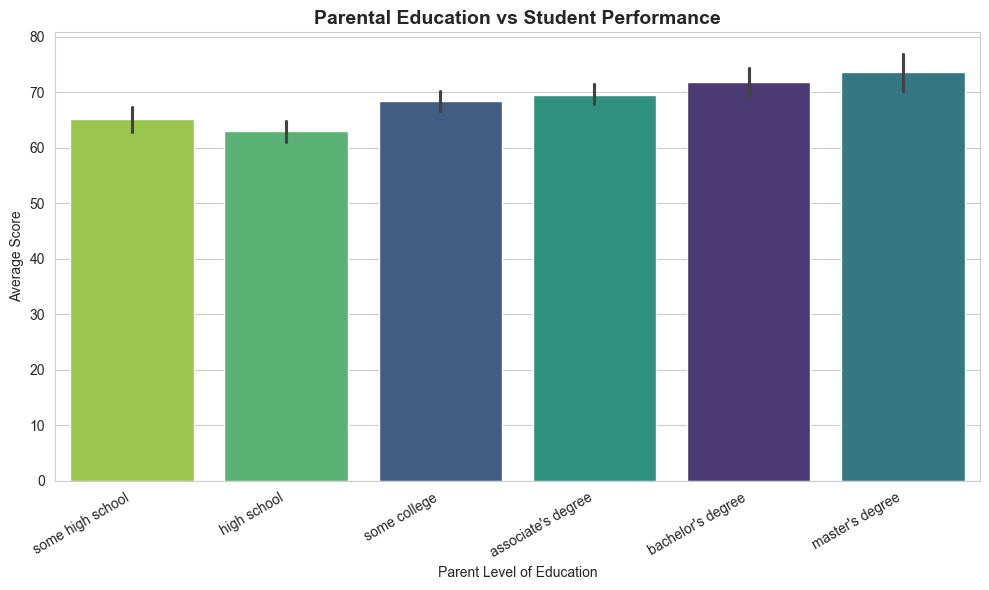

In [24]:
# Parental Education vs Student Performance
edu_order=["some high school","high school","some college",
           "associate's degree","bachelor's degree","master's degree"]
plt.figure(figsize=(10,6))
sns.barplot(data=df,x='parental level of education',y='average score',order=edu_order,
            hue='parental level of education',palette='viridis',legend=False)
plt.title('Parental Education vs Student Performance',fontsize=14,fontweight='bold')
plt.xlabel('Parent Level of Education')
plt.ylabel('Average Score')
plt.xticks(rotation=30,ha='right')
plt.tight_layout()
plt.show()


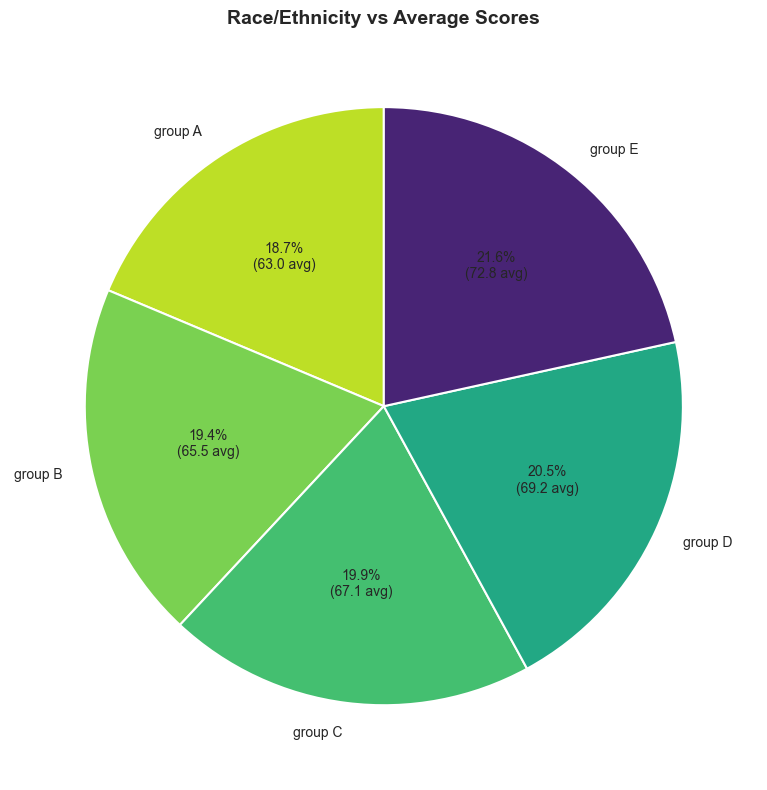

In [30]:
# Race/Ethnicity vs Average Scores
df = pd.read_csv("StudentsPerformance.csv")
df['average score'] = df[['math score', 'reading score', 'writing score']].mean(axis=1)

avg_by_race = df.groupby('race/ethnicity')['average score'].mean().sort_index()

colors = plt.cm.viridis_r([0.1, 0.2, 0.3, 0.4, 0.9])

plt.figure(figsize=(8, 8))
plt.pie(
    avg_by_race,
    labels=avg_by_race.index,
    autopct=lambda p: f'{p:.1f}%\n({p * avg_by_race.sum() / 100:.1f} avg)',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
plt.title('Race/Ethnicity vs Average Scores', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()